# Year One Deaths Investigation

Scenarios using a Nigeria population-by-age distribution and estimated survival curve appears to
show a large number of deaths in year one. This notebook aims to investigate the situation and
determine if there is a valid explanation (age distribution/survival curve mismatch) or a bug that
needs to be fixed.

In [1]:
from pathlib import Path

import numpy as np

from laser.core.utils import grid
from laser.core import PropertySet
from laser.core.demographics import load_pyramid_csv
from laser.core.demographics import AliasedDistribution
from laser.core.demographics import KaplanMeierEstimator
from laser.core.distributions import constant_float

from laser.generic import Model
from laser.generic.utils import ValuesMap
from laser.generic import SIR
from laser.generic.vitaldynamics import BirthsByCBR, MortalityByEstimator


## Setup

Let's set up a single node simulation with enough people to get good sampling. We will use the "troublesome" Nigeria age distribution and survival curve data.

In [2]:
MROWS = 1
NCOLS = 1
NTICKS = 365 * 5
POP = 10_000_000
scenario = grid(M=MROWS, N=NCOLS, population_fn=lambda x, y: POP // (MROWS * NCOLS))
params = PropertySet({"nticks": NTICKS})

birthrates = ValuesMap.from_scalar(30.0, MROWS * NCOLS, NTICKS)

# https://population.un.org/wpp/downloads?folder=Standard%20Projections&group=Population WPP2024_POP_F01_1_POPULATION_SINGLE_AGE_BOTH_SEXES.xlsx
nigeria = np.loadtxt(Path("data") / "Nigeria-Distribution-2020.csv")
pyramid = AliasedDistribution(nigeria)
# https://population.un.org/wpp/downloads?folder=Standard%20Projections&group=Mortality WPP2024_MORT_F04_1_LIFE_TABLE_SURVIVORS_BOTH_SEXES.xlsx
survival_data = np.loadtxt(Path("data") / "Nigeria-Survival-2020.csv", delimiter=",", usecols=1)
estimator = KaplanMeierEstimator(survival_data.cumsum())


## Run the Model

We will run the model without any transmission as we only care about the vital dynamics - mortality in particular.

In [3]:

model = Model(scenario, params, birthrates=birthrates)

model.components = [
    SIR.Susceptible(model),
    # SIR.Infectious(model, infdurdist=constant_float(7.0), infdurmin=1.0),
    # SIR.Recovered(model),
    BirthsByCBR(model, birthrates, pyramid, track=True),
    MortalityByEstimator(model, estimator)
]

model.run()


10,000,000 agents in 1 node(s): 100%|██████████| 1825/1825 [00:01<00:00, 1216.95it/s]


## Results

Let's plot the population (susceptible == population since we have no transmission) and births and deaths.

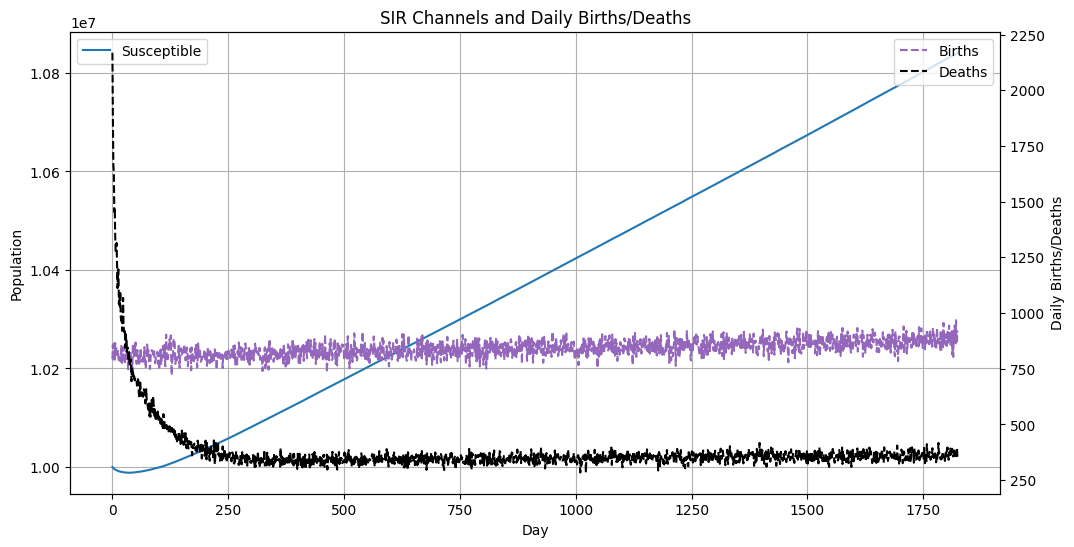

In [4]:
import matplotlib.pyplot as plt

def plot_sir_births_deaths(model):

    t = np.arange(model.params['nticks'])

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # SIR channels
    ax1.plot(model.nodes.S, label='Susceptible', color='tab:blue')
    if hasattr(model.nodes, 'I'):
        ax1.plot(model.nodes.I, label='Infectious', color='tab:red')
    if hasattr(model.nodes, 'R'):
        ax1.plot(model.nodes.R, label='Recovered', color='tab:green')
    ax1.set_xlabel('Day')
    ax1.set_ylabel('Population')
    ax1.legend(loc='upper left')
    ax1.grid()

    # Secondary axis for births and deaths
    ax2 = ax1.twinx()
    ax2.plot(model.nodes.births[:-1], label='Births', color='tab:purple', linestyle='--')
    ax2.plot(model.nodes.deaths[:-1], label='Deaths', color='black', linestyle='--')
    ax2.set_ylabel('Daily Births/Deaths')
    ax2.legend(loc='upper right')

    plt.title('SIR Channels and Daily Births/Deaths')
    plt.show()

plot_sir_births_deaths(model)

## Validate Population-by-Age Distribution

Let's plot the actual population by age vs. the distribution we put into the sampler.

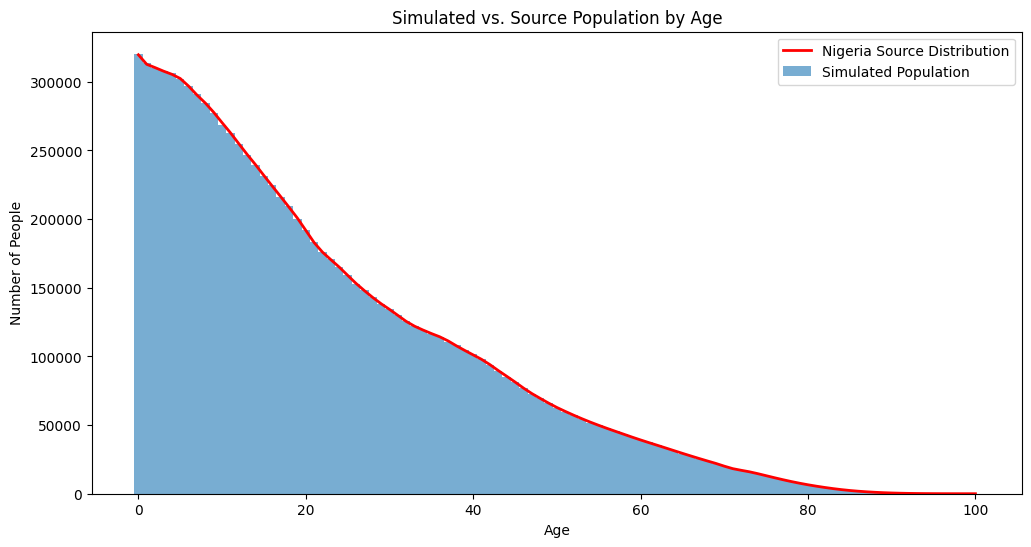

In [5]:
ages = (-model.people.dob // 365).astype(int)
max_age = len(nigeria)
hist, bins = np.histogram(ages, bins=np.arange(max_age + 1))

plt.figure(figsize=(12, 6))
plt.bar(bins[:-1], hist, width=1, alpha=0.6, label='Simulated Population')
plt.plot(np.arange(max_age), nigeria / nigeria.sum() * hist.sum(), label='Nigeria Source Distribution', color='red', linewidth=2)
plt.xlabel('Age')
plt.ylabel('Number of People')
plt.title('Simulated vs. Source Population by Age')
plt.legend()
plt.show()


## Validate Date-of-Death Estimation

Now let's look at the survival curves for individuals of different ages.

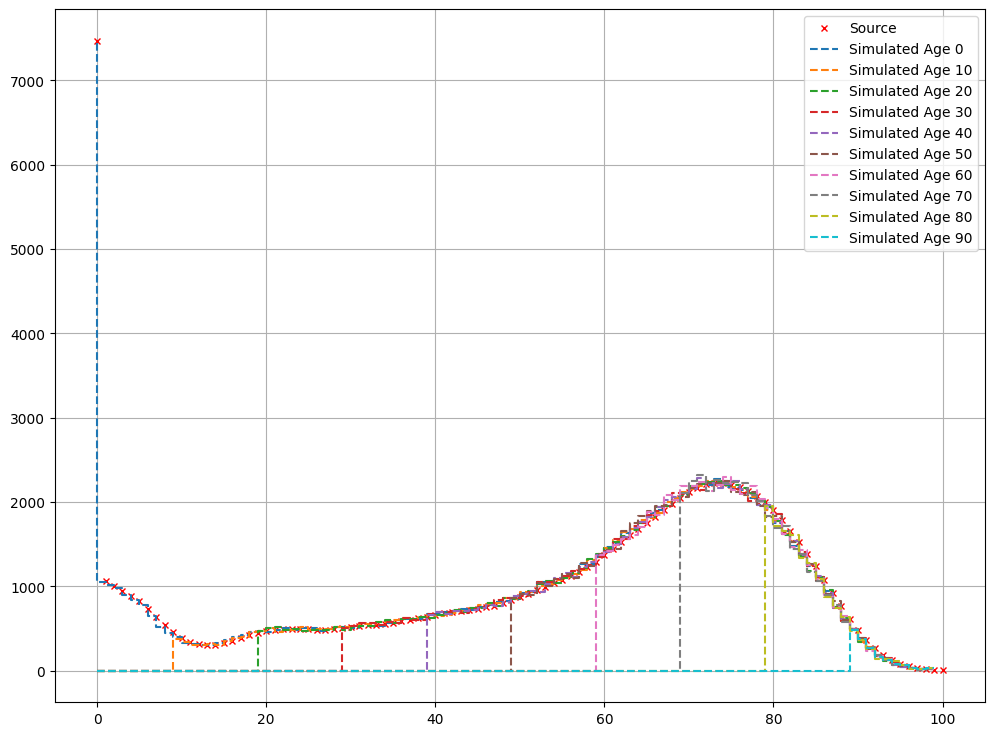

In [6]:
# For each age 0, 10, 20, ..., 90, plot the survival curve of the simulated population against the source survival curve
plt.figure(figsize=(12, 9))

age_at_death = (model.people.dod - model.people.dob) // 365

plt.plot(np.arange(0, 101), survival_data, 'rx', label="Source", markersize=4) # , alpha=0.7)

for age in range(0, 100, 10):
    agents = ages == age
    deaths_by_age, sim_bins = np.histogram(age_at_death[agents], bins=np.arange(0, 101))
    factor = survival_data[age:].sum() / deaths_by_age.sum()
    deaths_by_age = deaths_by_age * factor
    plt.step(sim_bins[:-1], deaths_by_age, label=f"Simulated Age {age}", linestyle="--")

plt.grid()

plt.legend(loc="upper right")
plt.show()


**Note the _very_ high number of deaths for newborns/neonates. Let's dig in to our data and the survival curve.**

In [7]:
for age in [0]: #range(0, 100, 10):
    agents = ages == age
    deaths_by_age, sim_bins = np.histogram(age_at_death[agents], bins=np.arange(0, 101))

    print(f"{age:<3} {agents.sum()=}")
    print(f"{deaths_by_age=}")
    print()

print(f"{survival_data=}")


0   agents.sum()=np.int64(320469)
deaths_by_age=array([23867,  3380,  3245,  3133,  2878,  2683,  2512,  2081,  1682,
        1444,  1265,  1073,  1015,   994,   985,  1042,  1162,  1266,
        1367,  1470,  1523,  1490,  1561,  1618,  1556,  1607,  1618,
        1512,  1589,  1652,  1651,  1641,  1687,  1701,  1717,  1820,
        1797,  1981,  1976,  1975,  2139,  2167,  2248,  2266,  2363,
        2312,  2433,  2505,  2609,  2654,  2726,  2957,  3010,  3356,
        3382,  3480,  3545,  3672,  4076,  4069,  4319,  4710,  4817,
        5220,  5357,  5667,  5990,  6113,  6266,  6604,  6735,  6985,
        7113,  7078,  7282,  6989,  6950,  6886,  6569,  6312,  6163,
        5610,  5327,  4741,  4409,  3980,  3522,  3018,  2415,  1905,
        1570,  1125,   870,   588,   422,   270,   157,   115,    54,
          61])

survival_data=array([7470., 1059., 1003.,  950.,  892.,  822.,  737.,  640.,  542.,
        455.,  386.,  339.,  312.,  303.,  310.,  329.,  357.,  388.,
        419.

One last comparison - let's scale the sampled population to the survival curve population (100_000) for easier comparison.

In [8]:
factor = survival_data[age:].sum() / deaths_by_age.sum()
print(f"{factor=}")
print(f"scaled deaths_by_age[0:10] =\n\t{np.round(deaths_by_age * factor)[0:10]} ...")
print(f"survival_data[0:10] =\n\t{survival_data[0:10]} ...")

factor=np.float64(0.31203954204618856)
scaled deaths_by_age[0:10] =
	[7447. 1055. 1013.  978.  898.  837.  784.  649.  525.  451.] ...
survival_data[0:10] =
	[7470. 1059. 1003.  950.  892.  822.  737.  640.  542.  455.] ...


## Conclusion

The large number of year one births are expected given a youth-weighted age distribution of the initial population coupled with a very high first year mortality rate (~7x larger than second year mortality).